# Dataset Preparation
We will start by taking a deeper look into the dataset and its features, and then do some preparation!

In [7]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [8]:
df =pd.read_csv('heart_attack.csv')
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,18,15,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,0,30,30,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,0,3,0,0,11,5,4


In [3]:
import os

# 1. Split the DataFrame into two parts
# Part 1: First 5 rows, first 8 columns
df_part1 = df.iloc[:5, :8] 

# Part 2: First 5 rows, remaining columns (from column 8 to the end)
df_part2 = df.iloc[:5, 8:]

# 2. Convert both parts to LaTeX strings.
# We use booktabs=True for the "modern" style
# We also use index=False to hide the 0,1,2,3... row numbers
latex_part1 = df_part1.to_latex(index=False)
latex_part2 = df_part2.to_latex(index=False)

# 3. Print the strings. You will copy/paste these into LaTeX.
# Create a subfolder named 'latex' if it doesn't exist
os.makedirs('latex', exist_ok=True)

# Save the LaTeX strings into separate files
with open('latex/part1.tex', 'w') as f1:
    f1.write(latex_part1)

with open('latex/part2.tex', 'w') as f2:
    f2.write(latex_part2)

print("LaTeX files have been saved in the 'latex/' subfolder.")

LaTeX files have been saved in the 'latex/' subfolder.


In [9]:
duplicated_df = df[df.duplicated(keep=False)]
class_percentages = duplicated_df['HeartDiseaseorAttack'].value_counts(normalize=True) * 100

print(class_percentages)

HeartDiseaseorAttack
0    98.357979
1     1.642021
Name: proportion, dtype: float64


In [10]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
42369,0,0,0,0,18.0,0,0,0,1,0,0,0,0,10,6,8
108949,0,0,0,0,18.0,0,0,0,1,0,0,0,0,10,6,8
17475,0,0,0,0,19.0,0,0,0,1,0,0,0,0,4,6,8
80704,0,0,0,0,19.0,0,0,0,1,0,0,0,0,4,6,8
19378,0,0,0,0,20.0,0,0,0,1,0,0,0,0,4,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79165,1,1,1,1,34.0,1,0,2,1,0,0,0,1,13,5,7
41787,1,1,1,1,36.0,0,0,2,1,0,0,0,1,10,6,8
93524,1,1,1,1,36.0,0,0,2,1,0,0,0,1,10,6,8
12309,1,1,1,1,36.0,1,0,2,0,0,0,20,1,9,4,5


In [11]:
df.dtypes

HeartDiseaseorAttack      int64
HighBP                    int64
HighChol                  int64
CholCheck                 int64
BMI                     float64
Smoker                    int64
Stroke                    int64
Diabetes                  int64
PhysActivity              int64
HvyAlcoholConsump         int64
MentHlth                  int64
PhysHlth                  int64
Sex                       int64
Age                       int64
Education                 int64
Income                    int64
dtype: object

In [12]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'HvyAlcoholConsump',
       'MentHlth', 'PhysHlth', 'Sex', 'Age', 'Education', 'Income'],
      dtype='object')

In [13]:
len(df)

129998

## Null Values

In [14]:
df.isnull().sum()

HeartDiseaseorAttack     0
HighBP                   0
HighChol                 0
CholCheck                0
BMI                     10
Smoker                   0
Stroke                   0
Diabetes                 0
PhysActivity             0
HvyAlcoholConsump        0
MentHlth                 0
PhysHlth                 0
Sex                      0
Age                      0
Education                0
Income                   0
dtype: int64

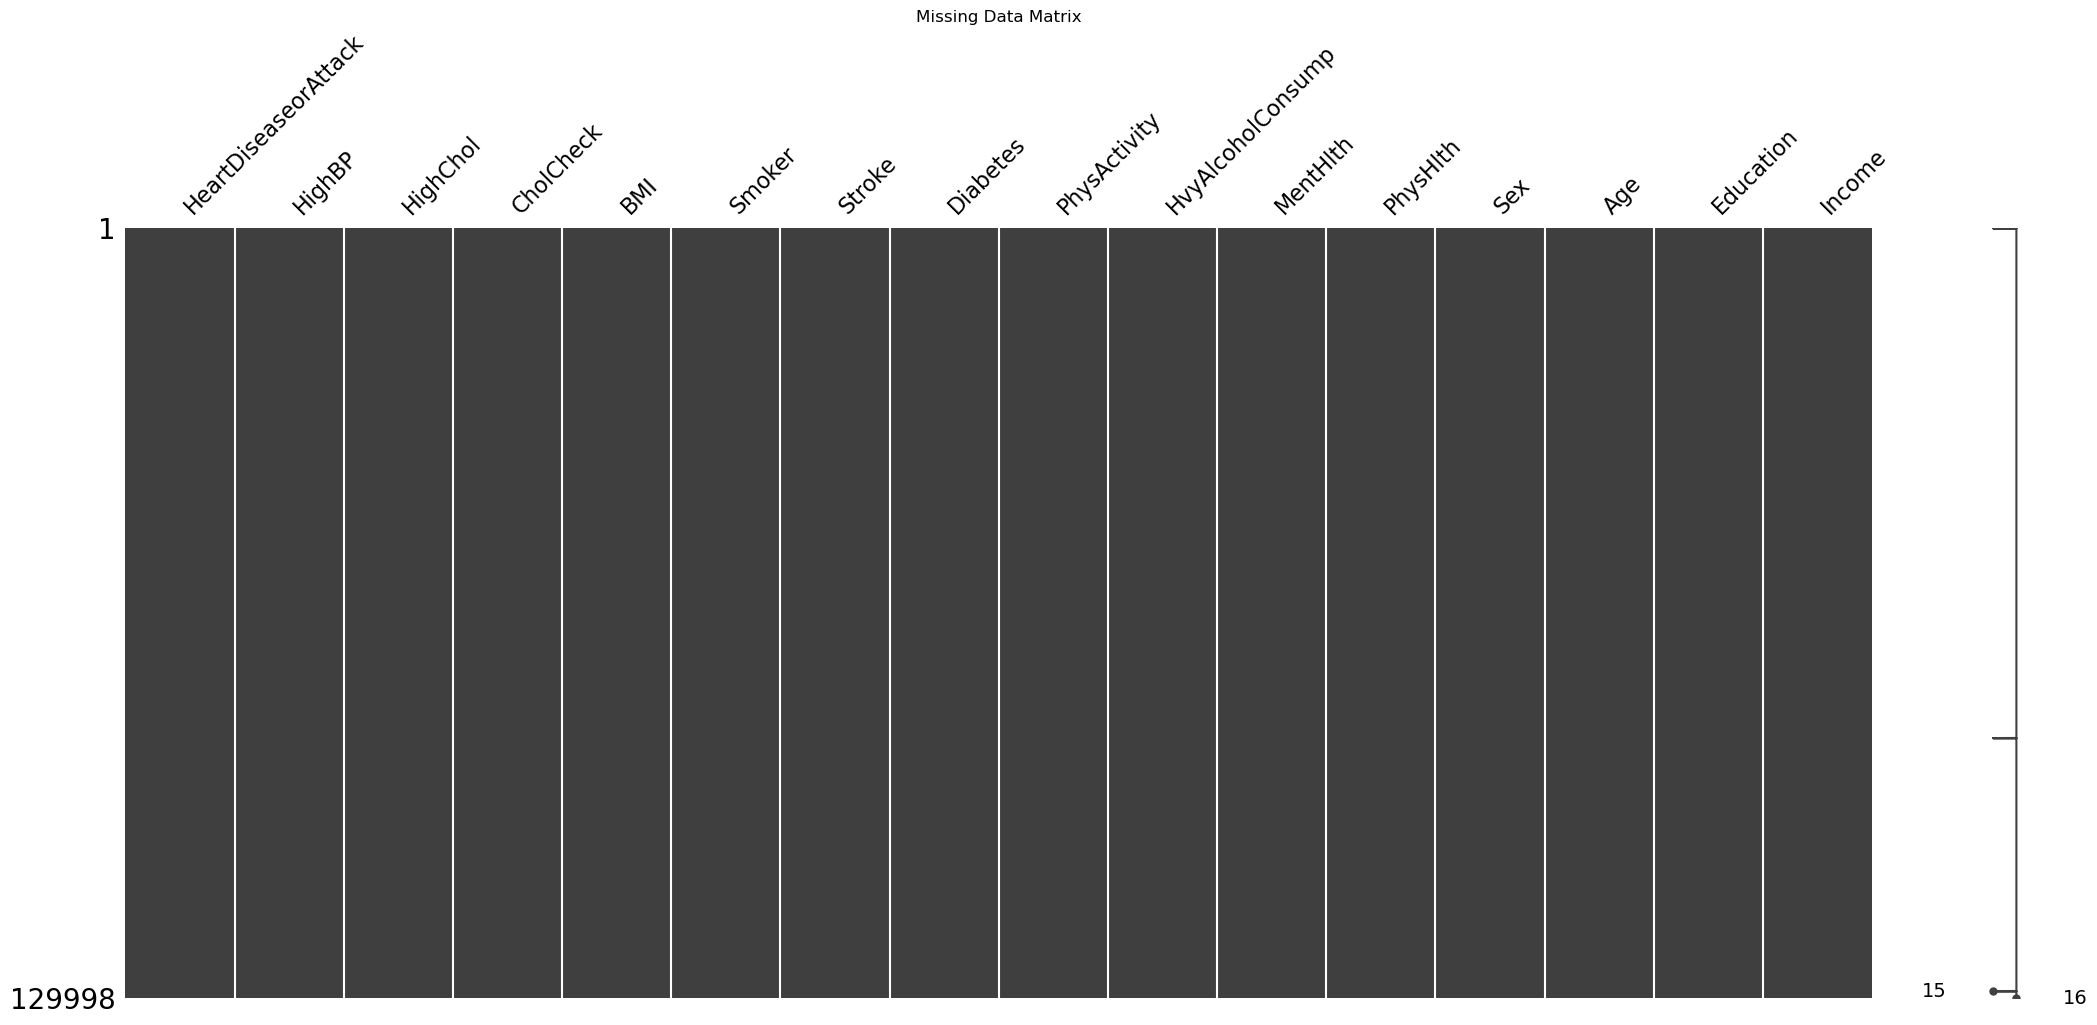

In [15]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.title('Missing Data Matrix')
plt.show()

We have null values and need to think about how to fill them:

Common options:
- Delete column -> Not good idea since its important
- Remove rows -> We have 129998 rows so we could just remove the 10
- Fill with median -> Usually good idea if too many rows have null to remove
- More advanced imputation like KNN,...

In [19]:
df['BMI'].isnull().mean() * 100

0.007692426037323651

### Deletion

In [20]:
df_dropped =df.dropna()
len(df_dropped)

129988

### Imputation

In [21]:
bmi_median = df['BMI'].median()
print(f"\nThe calculated median BMI is: {bmi_median}")

df_filled = df.fillna({'BMI': bmi_median})
len(df_filled)


The calculated median BMI is: 27.0


129998

In [22]:
df_filled.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
HvyAlcoholConsump       0
MentHlth                0
PhysHlth                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## Duplicates

In [23]:
df = df_dropped

In [24]:
df.duplicated().sum()

22961

In [25]:
all_duplicates = df[df.duplicated(keep=False)]

print("\n--- All Duplicates (Originals + Copies) ---")
print(all_duplicates)


--- All Duplicates (Originals + Copies) ---
        HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  \
5                          0       1         1          1  25.0       1   
7                          0       1         1          1  25.0       1   
25                         0       0         0          1  32.0       0   
29                         0       0         1          1  31.0       1   
35                         0       1         0          1  26.0       0   
...                      ...     ...       ...        ...   ...     ...   
129975                     0       0         0          1  24.0       1   
129982                     0       0         0          1  28.0       1   
129984                     0       0         0          1  24.0       0   
129987                     0       0         1          1  31.0       0   
129992                     0       1         0          1  27.0       0   

        Stroke  Diabetes  PhysActivity  HvyAlcoholCons

So we have quiet a lot of duplicates!
The question is if these are actual duplicates or people just have the exact same values:

#### Probability of a Duplicate Row

This (simplified) formula calculates the probability of a single, specific patient profile occurring by chance.

$$
P(\text{Row}) = P(\text{Age}) \times P(\text{Sex}) \times P(\text{BMI}) \times \dots \times P(\text{Income})
$$

##### Simplified Example (Just 5 of 16 Features)

Let's assume the following probabilities for a specific profile:

* $P(\text{Age}) \approx 0.1$ (1 in 10)
* $P(\text{Sex}) \approx 0.5$ (1 in 2)
* $P(\text{Education}) \approx 0.2$ (1 in 5)
* $P(\text{Income}) \approx 0.17$ (1 in 6)
* $P(\text{HighBP}) \approx 0.5$ (1 in 2)

The combined probability for just these 5 features is:

$$
P(\text{combo}) \approx 0.1 \times 0.5 \times 0.2 \times 0.17 \times 0.5 = 0.00085
$$

This is roughly a **1 in 1,176** chance.

**Conclusion:** When you multiply all 16 (often much smaller) probabilities, the final chance is so small (effectively 1-in-billions) that identical rows are almost certainly data errors.

In [26]:
df_cleaned = df.drop_duplicates()
len(df_cleaned)

107027

## Correlated Data

In [27]:
df = df_cleaned

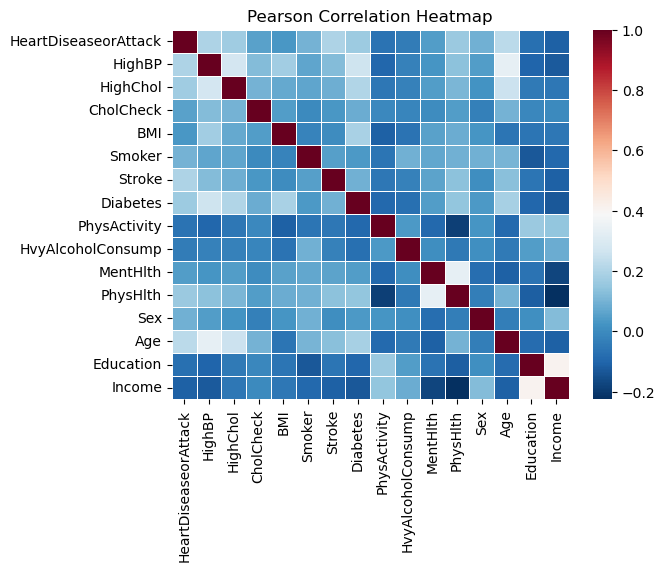

In [28]:
pearsoncorr=df.corr(method='pearson',numeric_only=True)

sb.heatmap(pearsoncorr,
            xticklabels=pearsoncorr.columns,
            yticklabels=pearsoncorr.columns,
            cmap='RdBu_r',
            annot=False,
            linewidth=0.5)

plt.title('Pearson Correlation Heatmap')
# Save the plot
plt.savefig('pearson_correlation_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()

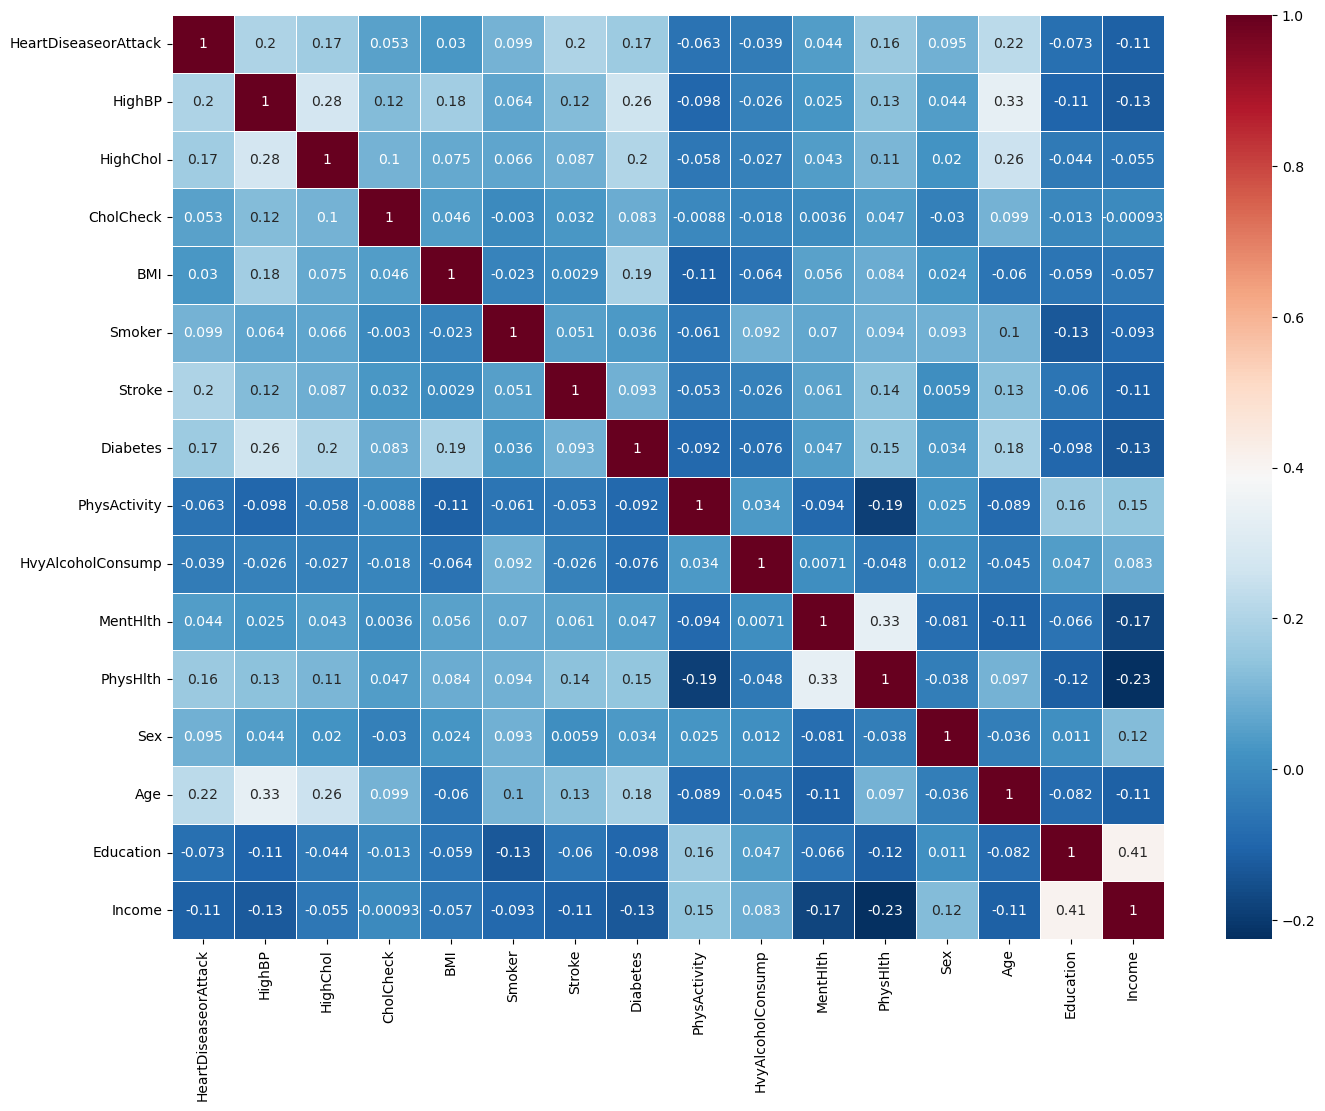

In [18]:
# Set the figure size (width, height) in inches
plt.figure(figsize=(16, 12))  # <-- Adjust (16, 12) as needed

# Your heatmap code is unchanged
sb.heatmap(pearsoncorr,
            xticklabels=pearsoncorr.columns,
            yticklabels=pearsoncorr.columns,
            cmap='RdBu_r',
            annot=True,
            linewidth=0.5)

plt.show() # <-- Add this to display the plot

If the correlation is > than |0.8| we should consider merging columns

**=> No values are correlated highly so we won't remove any features**

## Save prepared Dataset

In [20]:
df.to_csv('cleaned_heart_attack.csv', index=False)